In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/global-super-store-dataset/Global_Superstore2.csv


# SQL Style Business Analysis with Pandas

## Import Libraries

Import the required libraries for SQL-style data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Step 2 — Load Dataset**

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/muhammadumer7804/global-super-store-dataset/Global_Superstore2.csv",
    encoding="latin1"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (51290, 24)


# **Step 3 — Basic Exploration (SQL: SELECT *)**
Let's preview the dataset before performing SQL-style analysis.

In [4]:
print("=" * 60)
print("First 5 Rows")
print("=" * 60)

display(df.head())

First 5 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


SQL Concept

SELECT * FROM Global_Superstore
LIMIT 5;

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# **Step 4 — SQL Query #1 (SELECT)**


In SQL, we use the SELECT statement to retrieve specific columns.

The Pandas equivalent is selecting columns using double brackets.

SELECT

    Category,
    
    Sales,
    
    Profit FROM Global_Superstore;

In [6]:
selected_columns = df[["Category", "Sales", "Profit"]]

display(selected_columns.head())

,Category,Sales,Profit
0,Technology,2309.650,762.1845
1,Furniture,3709.395,-288.7650
2,Technology,5175.171,919.9710
3,Technology,2892.510,-96.5400
4,Technology,2832.960,311.5200


# **Step 5 — SQL Query #2 (WHERE)**

Filter the dataset to display only Technology products.

SELECT *

FROM Global_Superstore

WHERE Category = 'Technology';

In [7]:
technology_products = df[df["Category"] == "Technology"]

print("Technology Products:", technology_products.shape)

display(technology_products.head())

Technology Products: (10141, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
5,22732,IN-2013-42360,28-06-2013,01-07-2013,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,TEC-PH-10000030,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.675,5,0.1,763.2750,897.35,Critical


WHERE Category = 'Technology'

In [8]:
df[df["Category"] == "Technology"]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
5,22732,IN-2013-42360,28-06-2013,01-07-2013,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,TEC-PH-10000030,Technology,Phones,"Samsung Smart Phone, with Caller ID",2862.675,5,0.1,763.2750,897.35,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51151,43296,PL-2011-5380,07-04-2011,09-04-2011,Second Class,DB-2910,Daniel Byrd,Home Office,Poznan,Greater Poland,...,TEC-EPS-10003473,Technology,Machines,"Epson Phone, Wireless",80.970,1,0.0,36.4200,0.10,Medium
51178,47992,SU-2014-3390,02-01-2014,06-01-2014,Standard Class,JM-5250,Janet Martin,Consumer,Bur Sudan,Red Sea,...,TEC-MOT-10001088,Technology,Phones,"Motorola Audio Dock, VoIP",173.460,1,0.0,50.2800,0.09,Medium
51219,35382,CA-2013-111913,05-08-2013,07-08-2013,Second Class,LC-16930,Linda Cazamias,Corporate,Sacramento,California,...,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,302.384,2,0.2,30.2384,0.06,Medium
51237,31783,CA-2014-140963,11-06-2014,14-06-2014,First Class,MT-18070,Michelle Tran,Home Office,Los Angeles,California,...,TEC-PH-10001924,Technology,Phones,iHome FM Clock Radio with Lightning Dock,279.960,5,0.2,17.4975,0.05,High


# **Step 6 — SQL Query #3 (GROUP BY)**

SQL Query 3 - GROUP BY

Group the data by Category and calculate total sales for each category.

SELECT Category,

       SUM(Sales) AS Total_Sales
       FROM Global_Superstore

GROUP BY Category;

In [9]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .reset_index()
)

category_sales

,Category,Sales
0,Furniture,4.110874e+06
1,Office Supplies,3.787070e+06
2,Technology,4.744557e+06


# **Step 7 — SQL Query #4 (ORDER BY)**
SQL Query 4 - ORDER BY

Sort categories by total sales in descending order.

SELECT Category,

       SUM(Sales) AS Total_Sales
FROM Global_Superstore

GROUP BY Category

ORDER BY Total_Sales DESC;

In [10]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .reset_index()
      .sort_values(by="Sales", ascending=False)
)

category_sales

,Category,Sales
2,Technology,4.744557e+06
0,Furniture,4.110874e+06
1,Office Supplies,3.787070e+06


# **Step 8 — SQL Query #5 (Top 10 Customers)**
SQL Query 5 - Top Customers

Find the top 10 customers based on total sales.

SELECT Customer Name,

       SUM(Sales) AS Total_Sales
FROM Global_Superstore

GROUP BY Customer Name

ORDER BY Total_Sales DESC

LIMIT 10;

In [11]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .reset_index()
      .sort_values(by="Sales", ascending=False)
      .head(10)
)

top_customers

,Customer Name,Sales
758,Tom Ashbrook,40488.07080
731,Tamara Chand,37457.33300
313,Greg Tran,35550.95428
157,Christopher Conant,35187.07640
687,Sean Miller,35170.93296
73,Bart Watters,32310.44650
558,Natalie Fritzler,31781.25850
290,Fred Hopkins,30400.67452
347,Jane Waco,30288.45030
335,Hunter Lopez,30243.56658


# **Step 9 — SQL Query #6 (Top 10 Products
SQL Query 6 - Top Products

Find the top 10 products based on total sales.

SELECT Product Name,

       SUM(Sales) AS Total_Sales
       
FROM Global_Superstore

GROUP BY Product Name

ORDER BY Total_Sales DESC

LIMIT 10;

In [12]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .reset_index()
      .sort_values(by="Sales", ascending=False)
      .head(10)
)

top_products

,Product Name,Sales
310,"Apple Smart Phone, Full Size",86935.7786
970,"Cisco Smart Phone, Full Size",76441.5306
2415,"Motorola Smart Phone, Full Size",73156.3030
2501,"Nokia Smart Phone, Full Size",71904.5555
866,Canon imageCLASS 2200 Advanced Copier,61599.8240
1837,"Hon Executive Leather Armchair, Adjustable",58193.4841
2631,"Office Star Executive Leather Armchair, Adjust...",50661.6840
1714,"Harbour Creations Executive Leather Armchair, ...",50121.5160
2988,"Samsung Smart Phone, Cordless",48653.4600
2502,"Nokia Smart Phone, with Caller ID",47877.7857


# **Step 10 — Pivot Table (Most Important SQL Concept)**
SQL Query 7 - Pivot Table

Create a pivot table to analyze total sales by Region and Category.

SELECT Region,

       Category,
       
       SUM(Sales)
       
FROM Global_Superstore

GROUP BY Region, Category;

In [13]:
pivot_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

pivot_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Africa,194650.6350,266755.5330,3.223670e+05
Canada,10595.2800,30034.0800,2.629881e+04
Caribbean,118372.4000,89575.4160,1.163330e+05
Central,860417.5833,923435.2760,1.038450e+06
Central Asia,284362.9020,162766.3500,3.056973e+05
EMEA,228620.7360,276685.9920,3.008546e+05
East,208291.2040,205516.0550,2.649740e+05
North,377629.9180,374733.4530,4.958022e+05
North Asia,335716.4610,198554.7750,3.140385e+05


# **Step 11 (Charts)**


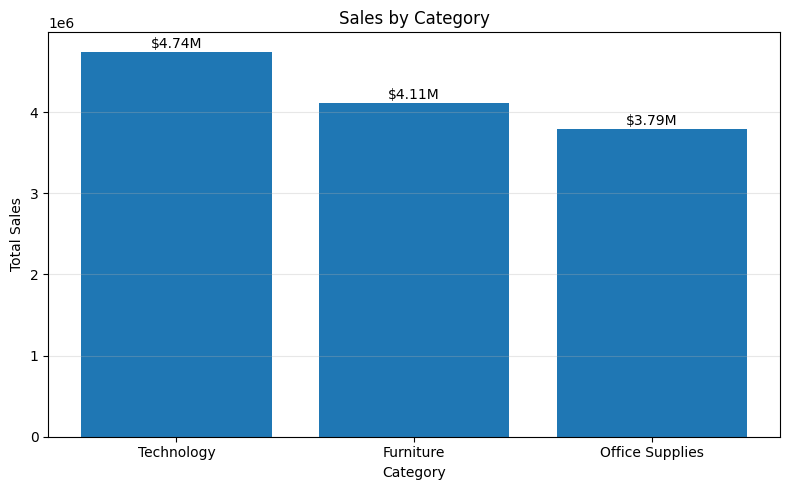

In [14]:

# Chart 1 : Sales by Category


plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Add Values on Bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50000,
        f"${height/1_000_000:.2f}M",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

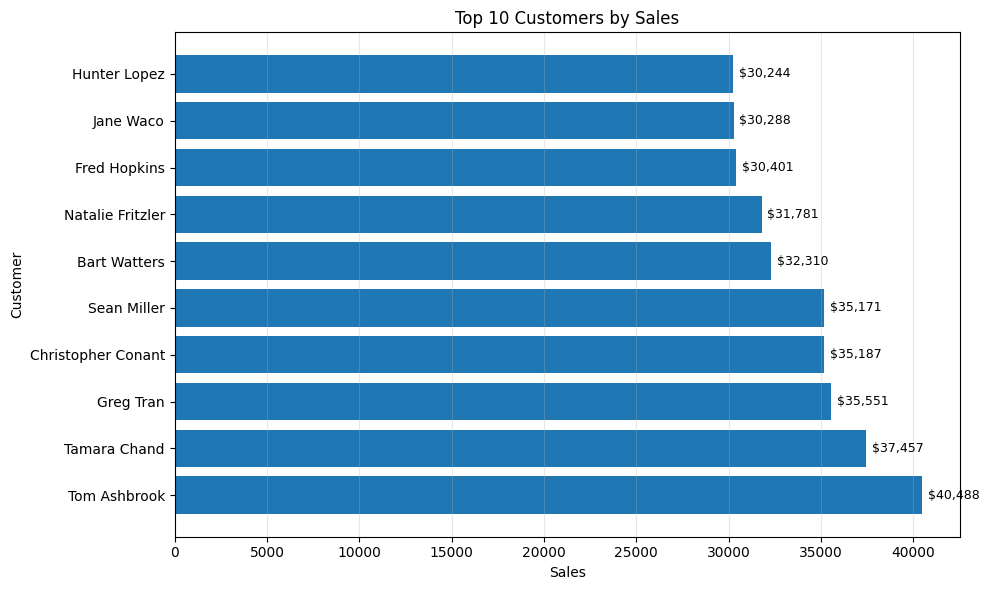

In [15]:


# Chart 2 : Top 10 Customers


plt.figure(figsize=(10,6))

bars = plt.barh(
    top_customers["Customer Name"],
    top_customers["Sales"]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

# Add Sales Labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 300,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

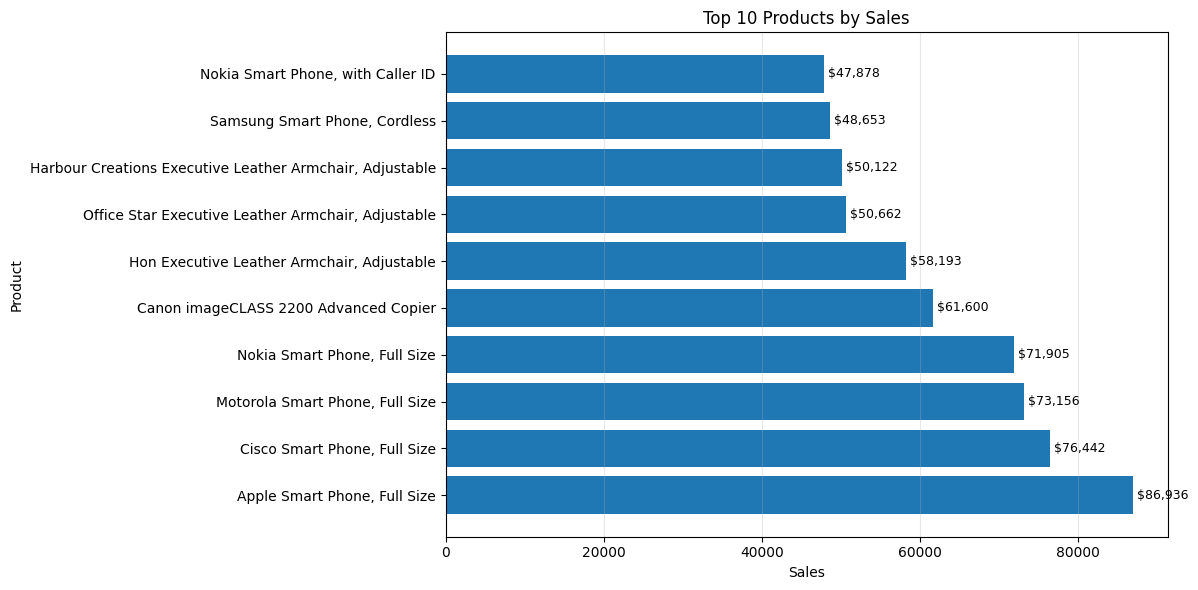

In [16]:

# Chart 3 : Top 10 Products


plt.figure(figsize=(12,6))

bars = plt.barh(
    top_products["Product Name"],
    top_products["Sales"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

# Add Sales Labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

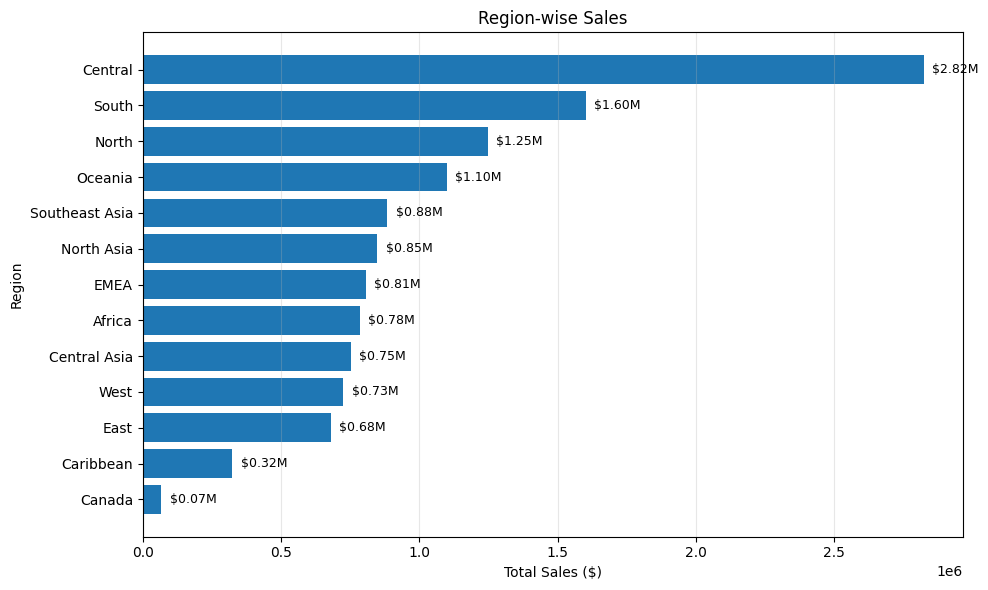

In [17]:

# Chart 4 : Region-wise Sales

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    region_sales.index,
    region_sales.values
)

plt.title("Region-wise Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Region")

# Add Sales Labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 30000,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.2f}M",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# **Step 12 — Business Insights**

- Technology is the highest revenue-generating category.
- A small number of customers contribute significantly to total sales.
- Smartphones are among the best-selling products.
- Sales performance varies across regions.
- Pivot table analysis helps identify strong product categories in each region.

# **Step 13 — Conclusion**

This project demonstrated SQL-style business analysis using Pandas.

The analysis included filtering, grouping, sorting, pivot tables, and data visualization to generate business insights.

This project showcases beginner-level SQL thinking with Python and Pandas.